# 03 — Sentiment Analysis (FinBERT)

Анализ тональности финансовых новостей с помощью **FinBERT** (ProsusAI/finbert):
- Загрузка новостей из `data/raw/{ticker}/news.json`
- Прогон через FinBERT (offline ETL)
- Агрегация sentiment по дням
- Сохранение в `data/processed/{ticker}/sentiment.parquet`

> Требует: `transformers`, `torch` (`uv add transformers torch`)

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "backend"))

RAW_DIR       = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

TICKERS = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA",
    "ORCL", "CRM", "ADBE", "AMD", "INTC", "QCOM", "TXN",
    "JPM", "BAC", "GS", "MS", "WFC", "BLK", "AXP",
    "JNJ", "UNH", "PFE", "ABT", "MRK", "TMO",
    "WMT", "HD", "MCD", "KO", "PG", "COST", "NKE",
    "XOM", "CVX", "CAT", "BA", "HON",
    "T", "VZ", "DIS", "V", "MA",
]
print(f"Root: {ROOT}")
print(f"Тикеров: {len(TICKERS)}")


Root: /Users/dvank1mang1/EquiSense
Тикеров: 44


## 1. Загрузка FinBERT

In [2]:
from transformers import pipeline

print("Загружаем FinBERT...")
finbert = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    tokenizer="ProsusAI/finbert",
    device=-1,
    truncation=True,
    max_length=512,
    top_k=None,
)
print("FinBERT загружен.")

Загружаем FinBERT...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 31275.23it/s]


BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT загружен.


## 2. Вспомогательные функции

In [3]:
def score_texts(texts: list[str], batch_size: int = 16) -> list[dict]:
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        outputs = finbert(batch)
        for out in outputs:
            scores = {item["label"].lower(): item["score"] for item in out}
            net = scores.get("positive", 0) - scores.get("negative", 0)
            results.append({
                "positive": scores.get("positive", 0),
                "negative": scores.get("negative", 0),
                "neutral":  scores.get("neutral",  0),
                "sentiment_score": net,
            })
    return results


def load_news_from_parquet(ticker: str, news_df: pd.DataFrame) -> list[dict]:
    """Loads news rows for a ticker from the flat news_raw.parquet."""
    rows = news_df[news_df["ticker"] == ticker]
    items = []
    for _, r in rows.iterrows():
        items.append({
            "title":     str(r.get("title", "") or ""),
            "summary":   str(r.get("summary", "") or ""),
            "published": str(r.get("published_at", "") or ""),
        })
    return items


print("Функции готовы.")


Функции готовы.


## 3. Прогон через FinBERT

In [4]:
# Загружаем все новости из единого файла
news_raw_path = RAW_DIR / "news_raw.parquet"
if not news_raw_path.exists():
    raise FileNotFoundError(f"news_raw.parquet не найден: {news_raw_path}. Запустите 01_data_collection.ipynb")

news_df = pd.read_parquet(news_raw_path)
print(f"Загружено {len(news_df)} новостей для {news_df['ticker'].nunique()} тикеров")

sentiment_frames = {}

for ticker in TICKERS:
    news_items = load_news_from_parquet(ticker, news_df)
    if not news_items:
        print(f"[SKIP] {ticker}: нет новостей")
        continue

    texts = []
    for item in news_items:
        text = (item["title"] + " " + item["summary"]).strip()[:512]
        if text:
            texts.append(text)

    if not texts:
        print(f"[SKIP] {ticker}: пустые тексты")
        continue

    scores = score_texts(texts)
    df_scores = pd.DataFrame(scores)
    df_scores["ticker"] = ticker

    sentiment_frames[ticker] = df_scores
    print(f"[{ticker}] {len(texts)} статей → "
          f"avg_score={df_scores['sentiment_score'].mean():.3f}")

print(f"\nГотово: {len(sentiment_frames)} тикеров")

# --- Агрегируем в статическую таблицу (одна строка на тикер) ---
rows = []
for ticker, df in sentiment_frames.items():
    rows.append({
        "ticker":           ticker,
        "sentiment_score":  df["sentiment_score"].mean(),
        "news_count":       len(df),
        "positive_ratio":   df["positive"].mean(),
        "negative_ratio":   df["negative"].mean(),
        "sentiment_std":    df["sentiment_score"].std(),
    })

sentiment_static = pd.DataFrame(rows).set_index("ticker")
print("\nСтатистика sentiment по тикерам:")
print(sentiment_static.sort_values("sentiment_score").to_string())

# Сохраняем
out_path = RAW_DIR / "sentiment_by_ticker.parquet"
sentiment_static.to_parquet(out_path)
print(f"\nСохранено → {out_path}")


Загружено 440 новостей для 44 тикеров


[AAPL] 10 статей → avg_score=0.399


[MSFT] 10 статей → avg_score=0.623


[GOOGL] 10 статей → avg_score=-0.050


[AMZN] 10 статей → avg_score=0.153


...

[T] 10 статей → avg_score=0.395


[VZ] 10 статей → avg_score=0.144


[DIS] 10 статей → avg_score=-0.130


[V] 10 статей → avg_score=0.104


[MA] 10 статей → avg_score=0.492

Готово: 44 тикеров

Статистика sentiment по тикерам:
        sentiment_score  news_count  positive_ratio  negative_ratio  sentiment_std
ticker                                                                            
ORCL          -0.672527          10        0.120723        0.793250       0.577553
HD            -0.297762          10        0.230781        0.528543       0.667846
NKE           -0.241564          10        0.302720        0.544285       0.755307
QCOM          -0.238565          10        0.234382        0.472947       0.717373
MCD           -0.214663          10        0.221317        0.435979       0.622616
UNH           -0.170299          10        0.234203        0.404502       0.686121
CAT           -0.167819          10        0.269017        0.436837       0.680966
INTC          -0.140369          10        0.143180        0.283549       0.486422
DIS           -0.130028          10        0.281691        0.411719       0.773930


## 4. Визуализация sentiment

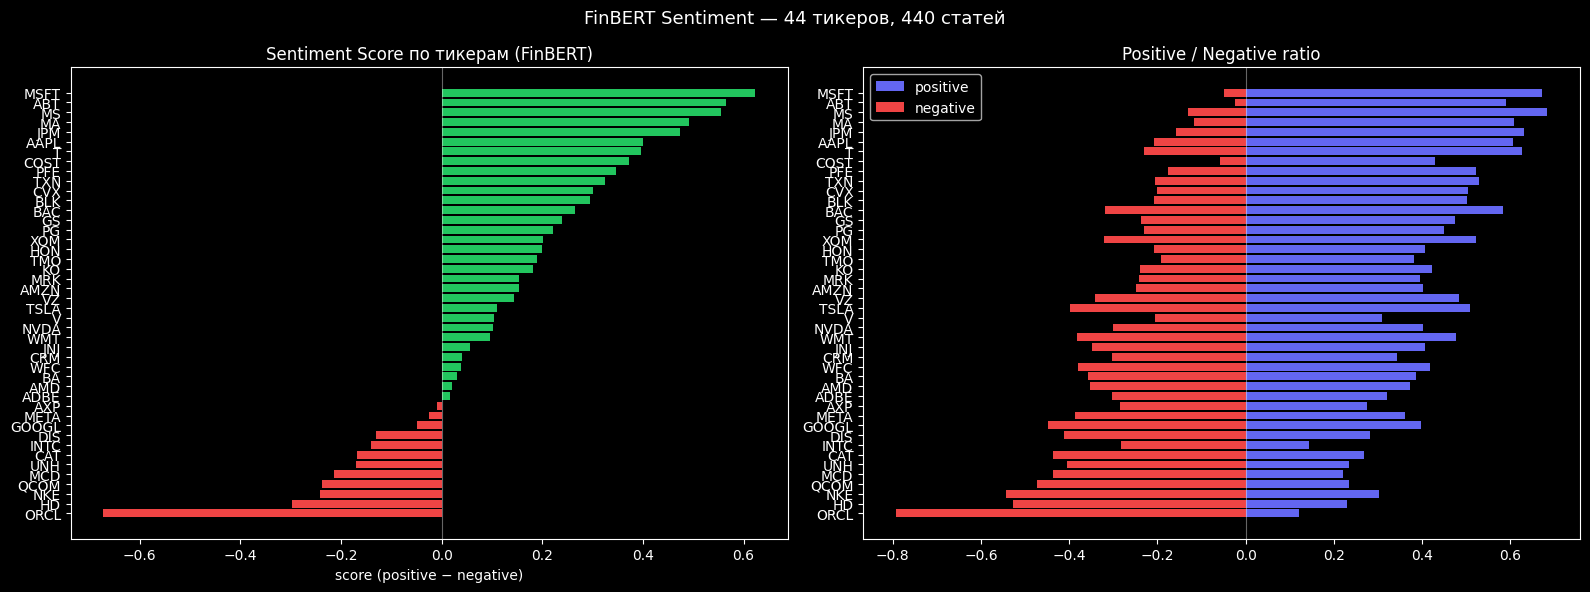

In [5]:
import matplotlib.pyplot as plt
plt.style.use("dark_background")

if not sentiment_frames:
    print("Нет данных для визуализации.")
else:
    # Перестраиваем sentiment_static из sentiment_frames для визуализации
    viz_df = sentiment_static.sort_values("sentiment_score")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    colors = ["#ef4444" if v < 0 else "#22c55e" for v in viz_df["sentiment_score"]]
    axes[0].barh(viz_df.index, viz_df["sentiment_score"], color=colors)
    axes[0].axvline(0, color="white", alpha=0.4, linewidth=0.8)
    axes[0].set_title("Sentiment Score по тикерам (FinBERT)")
    axes[0].set_xlabel("score (positive − negative)")

    axes[1].barh(viz_df.index, viz_df["positive_ratio"], color="#6366f1", label="positive")
    axes[1].barh(viz_df.index, -viz_df["negative_ratio"], color="#ef4444", label="negative")
    axes[1].axvline(0, color="white", alpha=0.4, linewidth=0.8)
    axes[1].set_title("Positive / Negative ratio")
    axes[1].legend()

    plt.suptitle(f"FinBERT Sentiment — {len(viz_df)} тикеров, {viz_df['news_count'].sum():.0f} статей", fontsize=13)
    plt.tight_layout()
    plt.show()
